In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
)

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

Dataset shape: (225745, 79)


In [3]:
print(df["Label"].value_counts())

Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [4]:
print(df["Label"].value_counts(normalize=True) * 100)

Label
DDoS      56.713105
BENIGN    43.286895
Name: proportion, dtype: float64


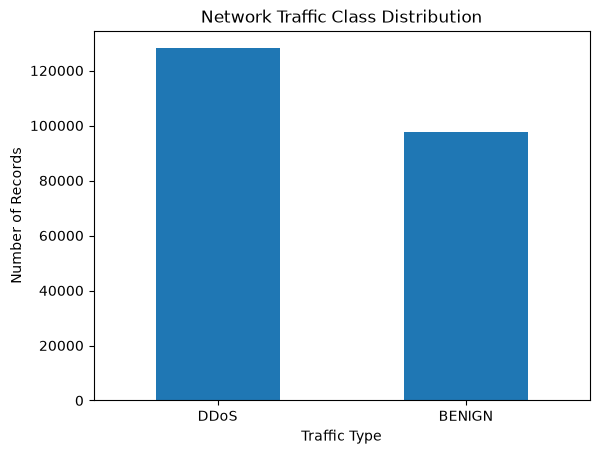

In [5]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Network Traffic Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [6]:
print(df.groupby("Label")["Flow Duration"].describe())

           count          mean           std  min       25%        50%  \
Label                                                                    
BENIGN   97718.0  1.530626e+07  3.215873e+07 -1.0     313.0   171388.5   
DDoS    128027.0  1.695559e+07  3.101261e+07  0.0  613093.0  1878978.0   

               75%          max  
Label                            
BENIGN  7519891.25  119999937.0  
DDoS    9387233.00  103941558.0  


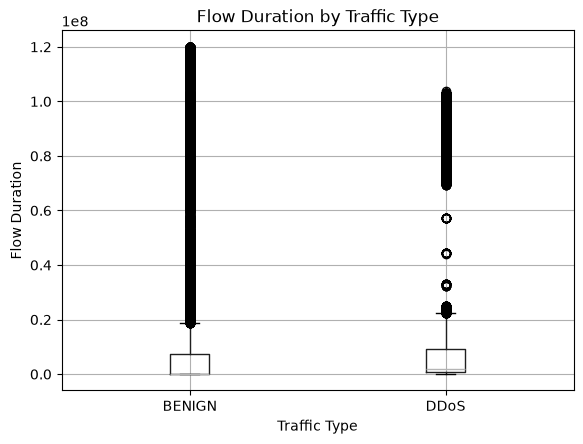

In [7]:
df.boxplot(
    column="Flow Duration",
    by="Label"
)

plt.title("Flow Duration by Traffic Type")
plt.suptitle("")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")
plt.show()

           count      mean        std  min  25%  50%  75%     max
Label                                                            
BENIGN   97718.0  5.402229  23.330287  1.0  1.0  2.0  5.0  1932.0
DDoS    128027.0  4.472439   1.897807  1.0  3.0  4.0  5.0    11.0


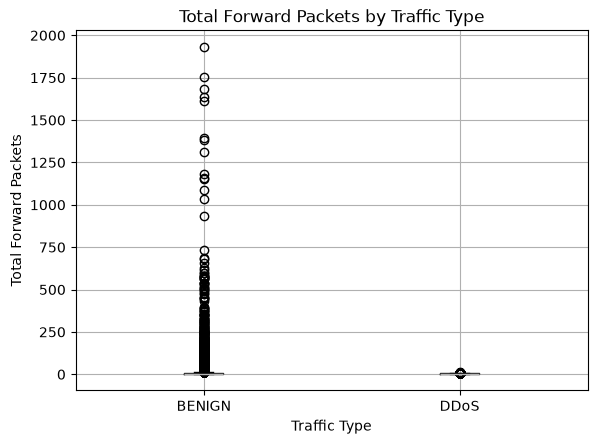

In [8]:
print(df.groupby("Label")["Total Fwd Packets"].describe())
df.boxplot(
    column="Total Fwd Packets",
    by="Label"
)

plt.title("Total Forward Packets by Traffic Type")
plt.suptitle("")
plt.xlabel("Traffic Type")
plt.ylabel("Total Forward Packets")
plt.show()

c:\Users\KIIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\KIIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


           count  mean  std           min       25%        50%           75%  \
Label                                                                          
BENIGN   97718.0   inf  NaN -2.000000e+06  0.988095  27.545364  10075.566750   
DDoS    128027.0   inf  NaN  3.686968e-02  0.495356   2.590679     13.026359   

        max  
Label        
BENIGN  inf  
DDoS    inf  


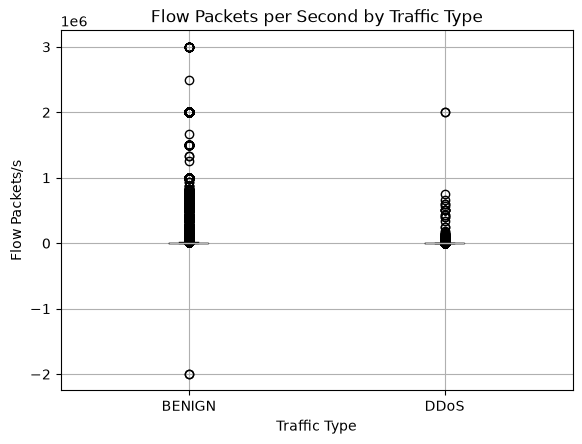

In [9]:
print(df.groupby("Label")["Flow Packets/s"].describe())
df.boxplot(
    column="Flow Packets/s",
    by="Label"
)

plt.title("Flow Packets per Second by Traffic Type")
plt.suptitle("")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Packets/s")
plt.show()

In [10]:
analysis_df = df.copy()

analysis_df["Flow Packets/s"] = analysis_df["Flow Packets/s"].replace(
    [np.inf, -np.inf],
    np.nan
)

print("NaN values:", analysis_df["Flow Packets/s"].isna().sum())

NaN values: 34


In [11]:
analysis_df["Flow Packets/s"] = analysis_df["Flow Packets/s"].fillna(
    analysis_df["Flow Packets/s"].median()
)

print("Remaining NaN:",
      analysis_df["Flow Packets/s"].isna().sum())

Remaining NaN: 0


           count          mean            std           min       25%  \
Label                                                                   
BENIGN   97718.0  32668.235880  172841.381602 -2.000000e+06  0.988095   
DDoS    128027.0    172.785976    9961.431717  3.686968e-02  0.495356   

              50%           75%        max  
Label                                       
BENIGN  27.355712  10000.000000  3000000.0  
DDoS     2.590679     13.025332  2000000.0  


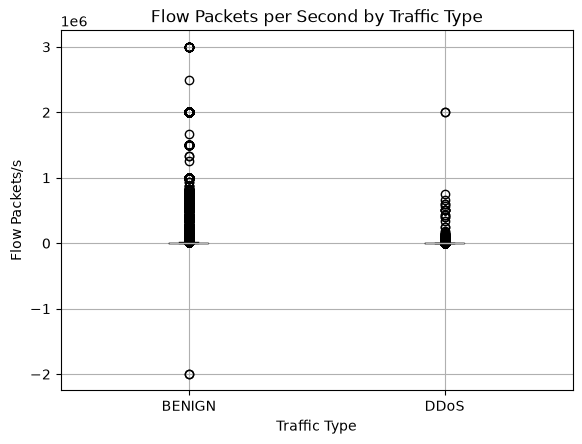

In [12]:
print(
    analysis_df.groupby("Label")["Flow Packets/s"].describe()
)
analysis_df.boxplot(
    column="Flow Packets/s",
    by="Label"
)

plt.title("Flow Packets per Second by Traffic Type")
plt.suptitle("")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Packets/s")
plt.show()

In [13]:
label_numeric = df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

print(label_numeric.value_counts())

Label
1    128027
0     97718
Name: count, dtype: int64


In [14]:
correlation_df = df.select_dtypes(include=np.number).copy()

correlation_df["Label"] = label_numeric

correlations = correlation_df.corr()["Label"].drop("Label")

print(correlations.sort_values(ascending=False).head(10))
print(correlations.sort_values().head(10))

Bwd Packet Length Mean    0.603299
Avg Bwd Segment Size      0.603299
Bwd Packet Length Max     0.577323
Bwd Packet Length Std     0.576155
Packet Length Mean        0.454283
Average Packet Size       0.453472
Packet Length Std         0.443749
Max Packet Length         0.414399
Packet Length Variance    0.408089
PSH Flag Count            0.247740
Name: Label, dtype: float64
Destination Port              -0.509798
URG Flag Count                -0.463190
Min Packet Length             -0.427396
min_seg_size_forward          -0.407315
Bwd Packet Length Min         -0.365667
Avg Fwd Segment Size          -0.356895
Fwd Packet Length Mean        -0.356895
Fwd Packet Length Max         -0.321529
Total Length of Fwd Packets   -0.319693
Subflow Fwd Bytes             -0.319693
Name: Label, dtype: float64


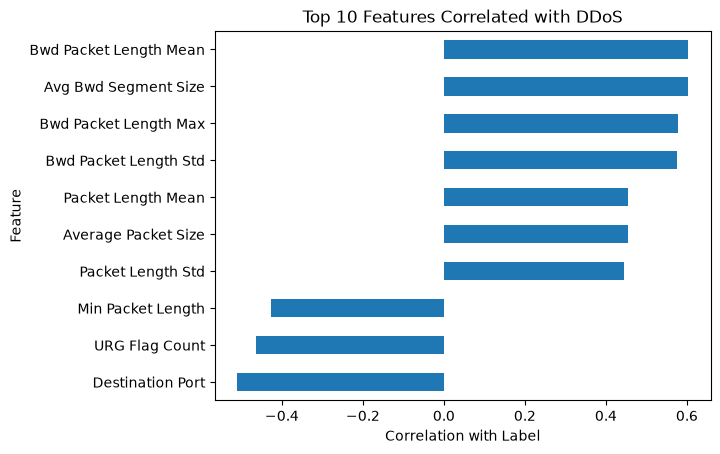

In [15]:
top_features = correlations.abs().sort_values(
    ascending=False
).head(10)

top_features = correlations[top_features.index]

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with DDoS")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")
plt.show()

In [16]:
feature_corr = df.select_dtypes(include=np.number).corr()

high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        corr_value = feature_corr.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append((
                feature_corr.columns[i],
                feature_corr.columns[j],
                corr_value
            ))

high_corr_pairs[:20]

[('Flow Duration', 'Flow IAT Max', np.float64(0.9202572641153036)),
 ('Flow Duration', 'Fwd IAT Total', np.float64(0.9970539718291673)),
 ('Flow Duration', 'Fwd IAT Max', np.float64(0.917945815778127)),
 ('Flow Duration', 'Idle Max', np.float64(0.9191990945209687)),
 ('Total Fwd Packets',
  'Total Backward Packets',
  np.float64(0.9567137090959984)),
 ('Total Fwd Packets',
  'Total Length of Bwd Packets',
  np.float64(0.9384698040256881)),
 ('Total Fwd Packets', 'Fwd Header Length', np.float64(0.968433776732758)),
 ('Total Fwd Packets', 'Bwd Header Length', np.float64(0.9287367502694539)),
 ('Total Fwd Packets', 'Fwd Header Length.1', np.float64(0.968433776732758)),
 ('Total Fwd Packets', 'Subflow Fwd Packets', np.float64(1.0)),
 ('Total Fwd Packets', 'Subflow Bwd Packets', np.float64(0.9567137090959984)),
 ('Total Fwd Packets', 'Subflow Bwd Bytes', np.float64(0.9384698040256881)),
 ('Total Backward Packets',
  'Total Length of Bwd Packets',
  np.float64(0.9704220020372479)),
 ('Total 

In [17]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df

,Feature 1,Feature 2,Correlation
0,Flow Duration,Flow IAT Max,0.920257
1,Flow Duration,Fwd IAT Total,0.997054
2,Flow Duration,Fwd IAT Max,0.917946
3,Flow Duration,Idle Max,0.919199
4,Total Fwd Packets,Total Backward Packets,0.956714
...,...,...,...
84,Subflow Bwd Packets,Subflow Bwd Bytes,0.970422
85,Active Mean,Active Max,0.934301
86,Active Mean,Active Min,0.982673
87,Idle Mean,Idle Max,0.952585


In [18]:
high_corr_df["Absolute Correlation"] = (
    high_corr_df["Correlation"].abs()
)

high_corr_df = high_corr_df.sort_values(
    "Absolute Correlation",
    ascending=False
)

high_corr_df.head(20)

,Feature 1,Feature 2,Correlation,Absolute Correlation
9,Total Fwd Packets,Subflow Fwd Packets,1.000000,1.000000
17,Total Backward Packets,Subflow Bwd Packets,1.000000,1.000000
19,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000,1.000000
78,RST Flag Count,ECE Flag Count,1.000000,1.000000
62,Fwd Header Length,Fwd Header Length.1,1.000000,1.000000
60,Fwd PSH Flags,SYN Flag Count,1.000000,1.000000
36,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,1.000000
30,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,1.000000
25,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,1.000000
75,Packet Length Mean,Average Packet Size,0.999357,0.999357


In [21]:
clean_df = df.copy()

clean_df = clean_df.replace(
    [np.inf, -np.inf],
    np.nan
)

clean_df["Flow Bytes/s"] = clean_df["Flow Bytes/s"].fillna(
    clean_df["Flow Bytes/s"].median()
)

clean_df["Flow Packets/s"] = clean_df["Flow Packets/s"].fillna(
    clean_df["Flow Packets/s"].median()
)

print("Remaining NaN:", clean_df.isnull().sum().sum())

Remaining NaN: 0


In [22]:
clean_feature_corr = clean_df.select_dtypes(
    include=np.number
).corr()

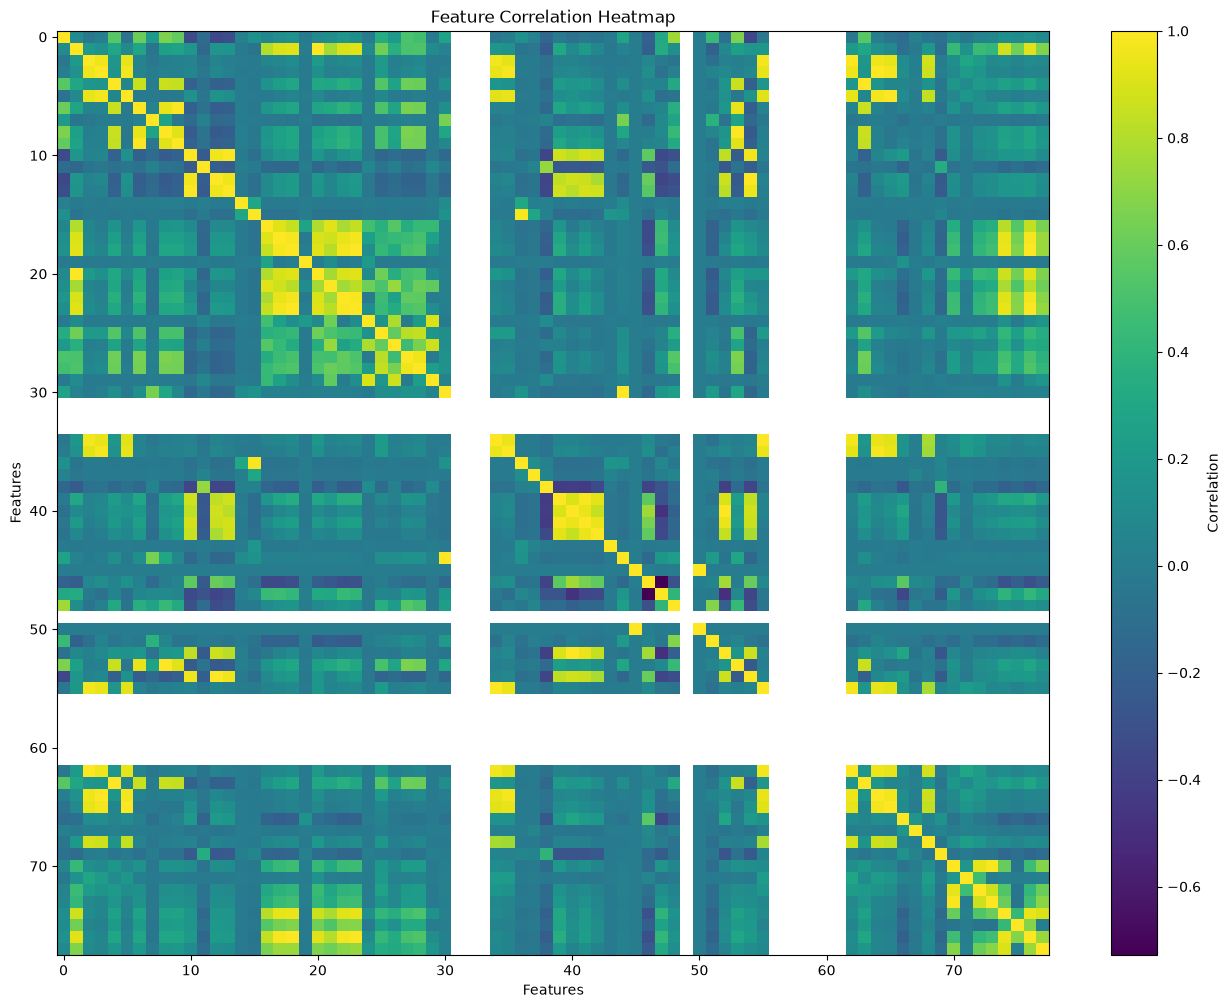

In [23]:
plt.figure(figsize=(16, 12))

plt.imshow(
    clean_feature_corr,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.title("Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [24]:
label_numeric = clean_df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

clean_corr_with_label = (
    clean_df
    .select_dtypes(include=np.number)
    .corr()["Label"]
    if "Label" in clean_df.select_dtypes(include=np.number).columns
    else None
)
feature_data = clean_df.select_dtypes(
    include=np.number
).copy()

feature_data["Target"] = label_numeric

label_correlations = (
    feature_data.corr()["Target"]
    .drop("Target")
    .sort_values(key=abs, ascending=False)
)

print(label_correlations.head(15))

Bwd Packet Length Mean    0.603299
Avg Bwd Segment Size      0.603299
Bwd Packet Length Max     0.577323
Bwd Packet Length Std     0.576155
Destination Port         -0.509798
URG Flag Count           -0.463190
Packet Length Mean        0.454283
Average Packet Size       0.453472
Packet Length Std         0.443749
Min Packet Length        -0.427396
Max Packet Length         0.414399
Packet Length Variance    0.408089
min_seg_size_forward     -0.407315
Bwd Packet Length Min    -0.365667
Avg Fwd Segment Size     -0.356895
Name: Target, dtype: float64


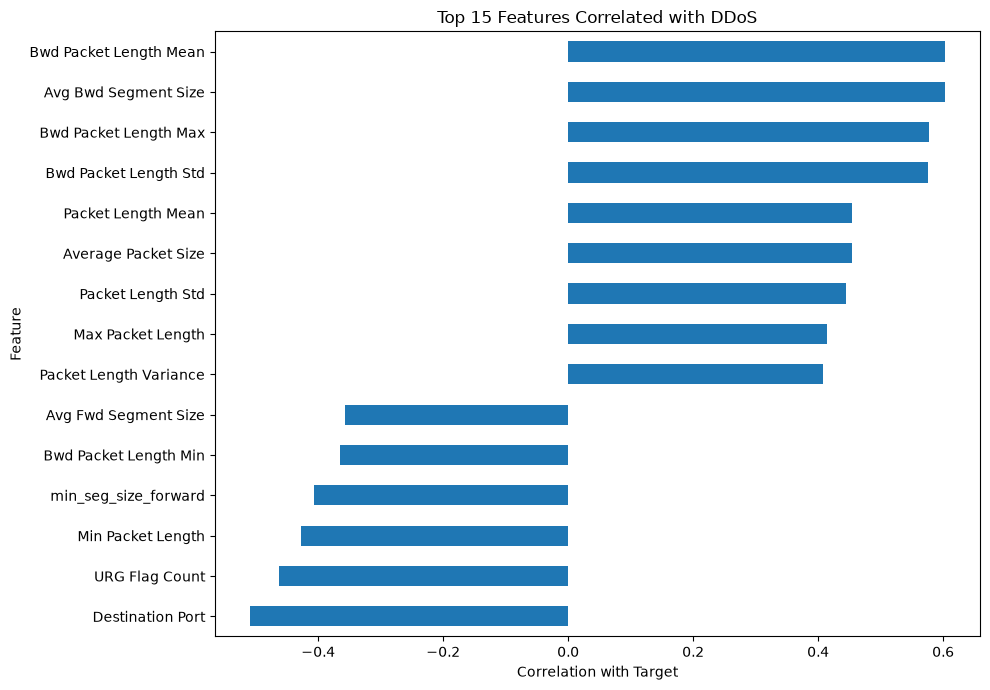

In [25]:
top_corr = label_correlations.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_corr.plot(kind="barh")

plt.title("Top 15 Features Correlated with DDoS")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 🛡️ Day 4 — Feature Analysis & Visualization

## Objective

Analyze the CICIDS2017 DDoS dataset to understand class distribution, feature behavior, relationships with the target, and feature redundancy.

## Class Distribution

- DDoS: 128,027 records (56.71%)
- BENIGN: 97,718 records (43.29%)

DDoS traffic is slightly more common in this dataset.

## Feature Comparison

Analyzed features including:

- Flow Duration
- Total Fwd Packets
- Flow Packets/s

### Flow Duration

Median values:

- BENIGN: 171,388.5
- DDoS: 1,878,978

DDoS flows have a higher median Flow Duration in this dataset.

### Total Fwd Packets

Median values:

- BENIGN: 2
- DDoS: 4

BENIGN traffic contains much larger extreme values, with a maximum of 1,932 compared with 11 for DDoS.

### Flow Packets/s

The raw feature contained infinite values because of zero-duration flows.

After replacing infinity with NaN and filling the affected values with the median:

- BENIGN median: 27.36
- DDoS median: 2.59

The feature is highly skewed and contains extreme values.

## Feature ↔ Target Correlation

The strongest positive correlations with the DDoS target were:

- Bwd Packet Length Mean: +0.603
- Avg Bwd Segment Size: +0.603
- Bwd Packet Length Max: +0.577
- Bwd Packet Length Std: +0.576
- Packet Length Mean: +0.454

Strong negative correlations included:

- Destination Port: -0.510
- URG Flag Count: -0.463
- Min Packet Length: -0.427
- min_seg_size_forward: -0.407

Correlation indicates linear association, not prediction accuracy.

## Feature Redundancy

A total of 89 feature pairs had absolute correlation ≥ 0.90.

Examples:

- Total Fwd Packets ↔ Subflow Fwd Packets: 1.000
- Total Backward Packets ↔ Subflow Bwd Packets: 1.000
- Total Length of Fwd Packets ↔ Subflow Fwd Bytes: 1.000
- Bwd Packet Length Mean ↔ Avg Bwd Segment Size: 1.000
- Fwd Packet Length Mean ↔ Avg Fwd Segment Size: 1.000
- Packet Length Mean ↔ Average Packet Size: 0.999

This shows significant feature redundancy in the dataset.

## Visualizations Created

- Network traffic class distribution
- Flow Duration box plot
- Total Forward Packets box plot
- Flow Packets/s box plot
- Feature correlation heatmap
- Top 15 features correlated with DDoS

## Key Learning

Exploratory Data Analysis helps us understand the dataset before training a model.

The dataset contains:

- Different feature distributions between DDoS and BENIGN traffic
- Highly skewed network features
- Extreme values
- Strong feature-to-target relationships
- Significant feature redundancy

These findings will help guide feature selection and model development in later stages.

## Day 4 Workflow

CICIDS2017
↓
Class distribution
↓
Feature comparison
↓
Visualization
↓
Correlation analysis
↓
Redundancy analysis
↓
Feature insights
↓
Preparation for Machine Learning